# ADA Semester Project

This represents the project for the CS-401 course at EPFL, done by:

| SCIPER                                              | Name                      |
|:----------------------------------------------------|:--------------------------|
| [356420](https://people.epfl.ch/badr.almahouri)     | Badr Al Mahouri           |
| [341237](https://people.epfl.ch/louis.grange)       | Louis Grange              |
| [340497](https://people.epfl.ch/daniel.alvesataide) | Daniel Ataíde             |
| [329310](https://people.epfl.ch/arnaud.tadic)       | Arnaud Jacques Yves Tadic |
| [308396](https://people.epfl.ch/yuri.cho)           | Yuri Cho                  |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xlrd import count_records

import src.data as utils


# Import dataset
We're using the reddit hyperlinks dataset. It's separated into 2 files: one for hyperlinks in the body of posts and the other for hyperlinks in the title of posts.
In addition, we have the embeddings dataset for subereddits and users. They represent each user or subreddit as a 300-dimensional vector, which we can use to compute similarities between them.

In [2]:
body_data, title_data, subreddits_data, users_data, events_data = utils.load_data()

Loading datasets from /Users/daniel/.cache/kagglehub/datasets/fejwiehf3928uhcwa/ada-2025-project-bald/versions/2
Completed


In [3]:
body_data

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,"1124.0,949.0,0.772241992883,0.0017793594306,0...."
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,"715.0,622.0,0.777622377622,0.00699300699301,0...."
...,...,...,...,...,...,...
286556,negareddit,debatefascism,68im20s,2017-04-30 16:31:26,1,"441.0,405.0,0.775510204082,0.0294784580499,0.0..."
286557,mildlynomil,justnomil,68imlas,2017-04-30 04:19:03,1,"2226.0,1855.0,0.786163522013,0.00224618149146,..."
286558,mmorpg,blackdesertonline,68ip5os,2017-04-30 16:54:08,1,"1100.0,909.0,0.778181818182,0.00181818181818,0..."
286559,electricskateboards,askreddit,68ipb2s,2017-04-30 16:41:53,1,"1876.0,1567.0,0.78144989339,0.00692963752665,0..."


In [4]:
title_data

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,"25.0,23.0,0.76,0.0,0.44,0.12,0.12,4.0,4.0,0.0,..."
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,"49.0,43.0,0.775510204082,0.0,0.265306122449,0...."
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,"14.0,14.0,0.785714285714,0.0,0.428571428571,0...."
...,...,...,...,...,...,...
571922,seattleshitshow,seattlewa,68iptp,2017-04-27 11:07:31,-1,"83.0,70.0,0.78313253012,0.0,0.10843373494,0.16..."
571923,peoplewhosayheck,spiderman,68iqh6s,2017-04-30 16:36:07,1,"121.0,105.0,0.719008264463,0.0165289256198,0.0..."
571924,vzla,wtf,68iqkcs,2017-04-30 15:50:07,1,"68.0,58.0,0.764705882353,0.0,0.147058823529,0...."
571925,denverbroncos,nfl,68iqt8,2017-04-30 16:11:30,-1,"96.0,79.0,0.770833333333,0.0,0.0729166666667,0..."


In [5]:
subreddits_data

,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
0,spiders,0.158972,0.285813,0.226329,-0.183338,-0.163159,-0.188910,0.422705,0.168602,0.178193,...,-0.025041,0.184655,0.111942,-1.125799,0.223129,-0.387323,-0.234882,-0.252297,-0.054315,0.500009
1,askreddit,-0.499114,0.323983,-0.424809,-0.222705,-0.327201,0.412856,1.040088,0.996697,-1.256240,...,0.072151,0.226658,0.535705,0.039861,-0.027087,-0.239952,0.554510,0.676439,-0.328846,0.941547
2,globaloffensivetrade,-0.023145,-1.199374,1.661484,-1.025296,1.424670,-1.179507,-1.035703,0.329301,-0.567272,...,2.998430,-1.235703,-0.326850,4.381238,-1.965378,-2.369674,-0.615389,2.010601,-0.919314,-2.149625
3,fireteams,2.492506,-2.529917,-0.448484,-3.543441,-0.586122,-0.101517,1.837567,-0.215715,-2.460388,...,-1.875214,0.969291,0.497958,2.941132,2.423561,1.315691,-0.959618,0.151845,-0.852492,-0.467526
4,funny,-0.819370,-0.865261,0.301753,0.018787,0.201029,0.070462,0.903895,1.038460,-0.306950,...,1.364194,0.830233,-0.137822,-2.204667,-0.162008,0.390291,-0.556404,0.322684,0.641634,1.320716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51273,33rd,-0.000076,-0.001643,-0.002896,0.000581,-0.003509,-0.000827,0.002095,0.000123,0.004370,...,-0.001570,-0.002246,0.003491,-0.004310,0.001598,0.005168,-0.001156,0.001575,-0.001938,0.001594
51274,bestofvic2015,-0.000203,0.012698,-0.007575,0.006486,-0.001693,0.004743,-0.002401,0.000121,0.001600,...,0.001392,0.001258,0.002970,-0.014106,-0.002713,-0.008648,0.003660,-0.005755,-0.001790,-0.001313
51275,aberystwyth,-0.001563,0.004733,-0.000082,-0.000982,-0.001511,0.001285,0.002187,0.002967,0.000660,...,0.002213,0.000520,-0.000564,-0.010018,0.002507,-0.000651,0.004169,-0.004672,0.002371,0.001073
51276,mail_forwarding,0.009269,0.024779,-0.017018,-0.007228,0.002351,0.003462,-0.008446,0.004544,0.022505,...,-0.002591,0.003482,0.001042,-0.002796,0.010739,-0.009148,0.000363,-0.003144,0.001945,-0.017272


In [6]:
users_data

,USER,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
0,rotoreuters,-0.224305,0.034301,-0.082651,0.004676,0.006960,0.892179,-0.309423,0.570185,0.492110,...,-0.380348,-0.144160,-0.289317,0.471727,-0.174092,0.534364,0.218821,0.269216,-0.412621,-0.469088
1,fiplefip,-0.306765,0.259314,-0.950335,0.560013,-0.364981,0.073359,-0.256642,-0.348088,-0.030323,...,-0.432182,-0.769793,-0.434484,0.268733,-0.163076,-0.455654,0.416560,-0.219805,-0.568944,-0.477788
2,amici_ursi,-0.234556,0.609160,-0.065395,-0.212264,0.269761,-0.562834,-0.455435,-0.349673,0.391979,...,0.622636,0.234270,0.083597,-0.647548,0.103007,0.344196,0.140004,0.579194,-0.046483,-0.705478
3,unremovable,0.253033,0.548086,-0.538728,0.375164,-0.129068,0.307664,-0.047697,-0.492977,0.224615,...,0.165165,-0.216920,-0.414641,-0.144242,0.185060,0.356242,0.095848,0.403010,-0.320782,-0.735368
4,CDRE_64,-0.008056,0.050560,-0.295054,-0.046483,0.042420,0.345231,0.075705,-0.198281,0.139585,...,-0.221219,-0.474621,-0.149465,-0.156034,-0.115828,-0.170805,0.284541,-0.144770,-0.050010,-0.341634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118376,rajkumareco,-0.069814,0.023679,0.032822,-0.200074,0.064771,0.157998,0.053184,-0.124960,-0.068105,...,-0.030709,-0.097185,0.029929,-0.067463,-0.265459,-0.201405,0.254439,0.006016,0.013839,0.105910
118377,roryswife,-0.102751,-0.008857,-0.131908,-0.154319,-0.023083,0.022363,0.090508,-0.034480,-0.033439,...,-0.084732,-0.160888,-0.036171,-0.049265,-0.040469,-0.160486,0.059213,0.051630,0.093915,-0.017583
118378,shillagepeople,0.008636,0.067610,-0.133499,-0.057814,0.047882,0.027176,0.047853,-0.066698,-0.047510,...,-0.031517,-0.191591,-0.032287,0.034490,-0.041353,-0.125495,0.162754,0.004968,-0.006810,-0.037618
118379,trizock,0.101569,0.050567,-0.096631,-0.068904,-0.047230,0.123565,-0.131402,-0.131583,-0.143453,...,-0.076321,0.071303,-0.040878,0.047556,0.079397,-0.050565,0.107052,0.139607,-0.064489,-0.177276


# Methods (POC)
We wish to implement different methods to analyze the data. Here are some proof of concepts.

To preprocess the data, we wish to do the following:
- Reduce dataset to only include active subreddits ( >100 posts as source or target)
- Apply KNN clustering to the subreddits embeddings dataset to find similar subreddits.
- Manually pick some clusters related to commerce.
- Filter the subreddits (low-activity, non-English, other)
- Provide a finished list of subreddits to be used in the analysis.

In [7]:
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

# Counting how many appearances each subreddit has as 'SOURCE_SUBREDDIT'

count_source_body = body_data['SOURCE_SUBREDDIT'].value_counts().reset_index()
count_source_body.columns = ['SUBREDDIT', 'POST_COUNT_BODY']

count_source_title = title_data['SOURCE_SUBREDDIT'].value_counts().reset_index()
count_source_title.columns = ['SUBREDDIT', 'POST_COUNT_TITLE']

combined_source_counts = pd.merge(count_source_body, count_source_title, on='SUBREDDIT', how='outer').fillna(0)

combined_source_counts['POST_COUNT_SOURCE'] = combined_source_counts['POST_COUNT_BODY'] + combined_source_counts['POST_COUNT_TITLE']

source_count = pd.merge(subreddits_data[['SUBREDDIT']], combined_source_counts,
                            on='SUBREDDIT', how='left')

source_count.dropna(subset=['POST_COUNT_SOURCE'], inplace=True)
source_count[source_count['POST_COUNT_SOURCE'] > 100].sort_values(by='POST_COUNT_SOURCE', ascending=False)


,SUBREDDIT,POST_COUNT_BODY,POST_COUNT_TITLE,POST_COUNT_SOURCE
495,subredditdrama,4665.0,22971.0,27636.0
381,bestof,0.0,21170.0,21170.0
1633,titlegore,3.0,9500.0,9503.0
1289,shitredditsays,501.0,7338.0,7839.0
1431,drama,1306.0,5478.0,6784.0
...,...,...,...,...
20889,shitleftistssay,7.0,94.0,101.0
1219,climbing,30.0,71.0,101.0
3173,baconreader,80.0,21.0,101.0
29056,soviethistory,1.0,100.0,101.0


In [8]:
# Counting how many appearances each subreddit has 'TARGET_SUBREDDIT'
count_target_body = body_data['TARGET_SUBREDDIT'].value_counts().reset_index()
count_target_body.columns = ['SUBREDDIT', 'POST_COUNT_BODY']

count_target_title = title_data['TARGET_SUBREDDIT'].value_counts().reset_index()
count_target_title.columns = ['SUBREDDIT', 'POST_COUNT_TITLE']

combined_target_counts = pd.merge(count_target_body, count_target_title, on='SUBREDDIT', how='outer').fillna(0)

combined_target_counts['POST_COUNT_TARGET'] = combined_target_counts['POST_COUNT_BODY'] + combined_target_counts['POST_COUNT_TITLE']

target_count = pd.merge(subreddits_data[['SUBREDDIT']], combined_target_counts,
                            on='SUBREDDIT', how='left')

target_count.dropna(subset=['POST_COUNT_TARGET'], inplace=True)
target_count[target_count['POST_COUNT_TARGET'] > 100].sort_values(by='POST_COUNT_TARGET', ascending=False)


,SUBREDDIT,POST_COUNT_BODY,POST_COUNT_TITLE,POST_COUNT_TARGET
1,askreddit,7329.0,19293.0,26622.0
456,iama,3694.0,9752.0,13446.0
10,pics,2779.0,9799.0,12578.0
33,todayilearned,2371.0,8753.0,11124.0
4,funny,2046.0,8731.0,10777.0
...,...,...,...,...
9732,aislingduval,33.0,68.0,101.0
4229,connery,15.0,86.0,101.0
713,beyondthebump,36.0,65.0,101.0
2195,patientgamers,37.0,64.0,101.0


In [9]:
# Total appearances as SOURCE or TARGET
total_counts = pd.merge(source_count, target_count, on='SUBREDDIT', how='outer', suffixes=('_SOURCE', '_TARGET')).fillna(0)
total_counts['POST_COUNT_TOTAL'] = total_counts['POST_COUNT_SOURCE'] + total_counts['POST_COUNT_TARGET']
total_counts[total_counts['POST_COUNT_TOTAL'] > 100].sort_values(by='POST_COUNT_TOTAL', ascending=False)[['SUBREDDIT', 'POST_COUNT_TOTAL']]

# Finally filter subreddits_data to only include subreddits with more than 100 total posts
active_subreddits = subreddits_data[subreddits_data['SUBREDDIT'].isin(total_counts[total_counts['POST_COUNT_TOTAL'] > 100]['SUBREDDIT'])]
subreddits_name = active_subreddits['SUBREDDIT']
# export to csv
subreddits_name.to_csv('subreddits_names.csv', index=False)

In [10]:
columns_show = ['SUBREDDIT', 'POST_COUNT_SOURCE', 'POST_COUNT_TARGET', 'POST_COUNT_TOTAL']

total_counts.sort_values(by='POST_COUNT_TOTAL', ascending=False)[columns_show][:25]

,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
26148,subredditdrama,27636.0,3507.0,31143.0
1942,askreddit,1338.0,26622.0,27960.0
3038,bestof,21170.0,1459.0,22629.0
13097,iama,1187.0,13446.0,14633.0
20681,pics,253.0,12578.0,12831.0
27930,todayilearned,1294.0,11124.0,12418.0
10614,funny,979.0,10777.0,11756.0
29562,videos,341.0,10013.0,10354.0
30618,worldnews,303.0,9944.0,10247.0
27886,titlegore,9503.0,33.0,9536.0


## K-Means Clustering Visualization

In [11]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

embeddings = active_subreddits.drop(columns=['SUBREDDIT'])
embeddings_norm = normalize(embeddings, norm='l2')

pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_norm)

print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")

kmeans = KMeans(n_clusters=25, n_init=50, max_iter=1000, random_state=42)
labels_kmeans = kmeans.fit_predict(embeddings_pca)

labels_kmeans = []
for n_clusters in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, max_iter=1000, random_state=42)
    labels_kmeans.append(kmeans.fit_predict(embeddings_pca))

for name, labels in {
    "KMeans_5": labels_kmeans[0],
    "KMeans_10": labels_kmeans[1],
    "KMeans_15": labels_kmeans[2],
    "KMeans_20": labels_kmeans[3],
    "KMeans_25": labels_kmeans[4],
    "KMeans_30": labels_kmeans[5],
    "KMeans_35": labels_kmeans[6],
    "KMeans_40": labels_kmeans[7],
    "KMeans_45": labels_kmeans[8],
    "KMeans_50": labels_kmeans[9],
}.items():
    if len(set(labels)) > 1: 
        print(f"{name:8s} | Silhouette: {silhouette_score(embeddings_pca, labels):.3f} | "
              f"Davies-Bouldin: {davies_bouldin_score(embeddings_pca, labels):.3f}")

Explained variance ratio: 0.94
KMeans_5 | Silhouette: 0.108 | Davies-Bouldin: 2.482
KMeans_10 | Silhouette: 0.097 | Davies-Bouldin: 2.157
KMeans_15 | Silhouette: 0.108 | Davies-Bouldin: 2.226
KMeans_20 | Silhouette: 0.112 | Davies-Bouldin: 2.132
KMeans_25 | Silhouette: 0.111 | Davies-Bouldin: 2.139
KMeans_30 | Silhouette: 0.118 | Davies-Bouldin: 2.113
KMeans_35 | Silhouette: 0.112 | Davies-Bouldin: 2.160
KMeans_40 | Silhouette: 0.119 | Davies-Bouldin: 2.147
KMeans_45 | Silhouette: 0.109 | Davies-Bouldin: 2.107
KMeans_50 | Silhouette: 0.117 | Davies-Bouldin: 2.079


In [12]:
# Helper function: scalable distinct color palette
def get_cluster_colors(n_clusters):
    """
    Return a list of colors that can handle up to ~60 distinct clusters
    using a combination of tab20, tab20b, and tab20c colormaps.
    """
    colors = np.vstack((
        plt.cm.tab20(np.linspace(0, 1, 20)),
        plt.cm.tab20b(np.linspace(0, 1, 20)),
        plt.cm.tab20c(np.linspace(0, 1, 20))
    ))
    if n_clusters > len(colors):
        # fallback to continuous color map if more than ~60 clusters
        colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_clusters))
    else:
        colors = colors[:n_clusters]
    return colors


PERFORMING K-MEANS WITH K=30

Reducing 50D embeddings to 2D using t-SNE...
This may take a few minutes...


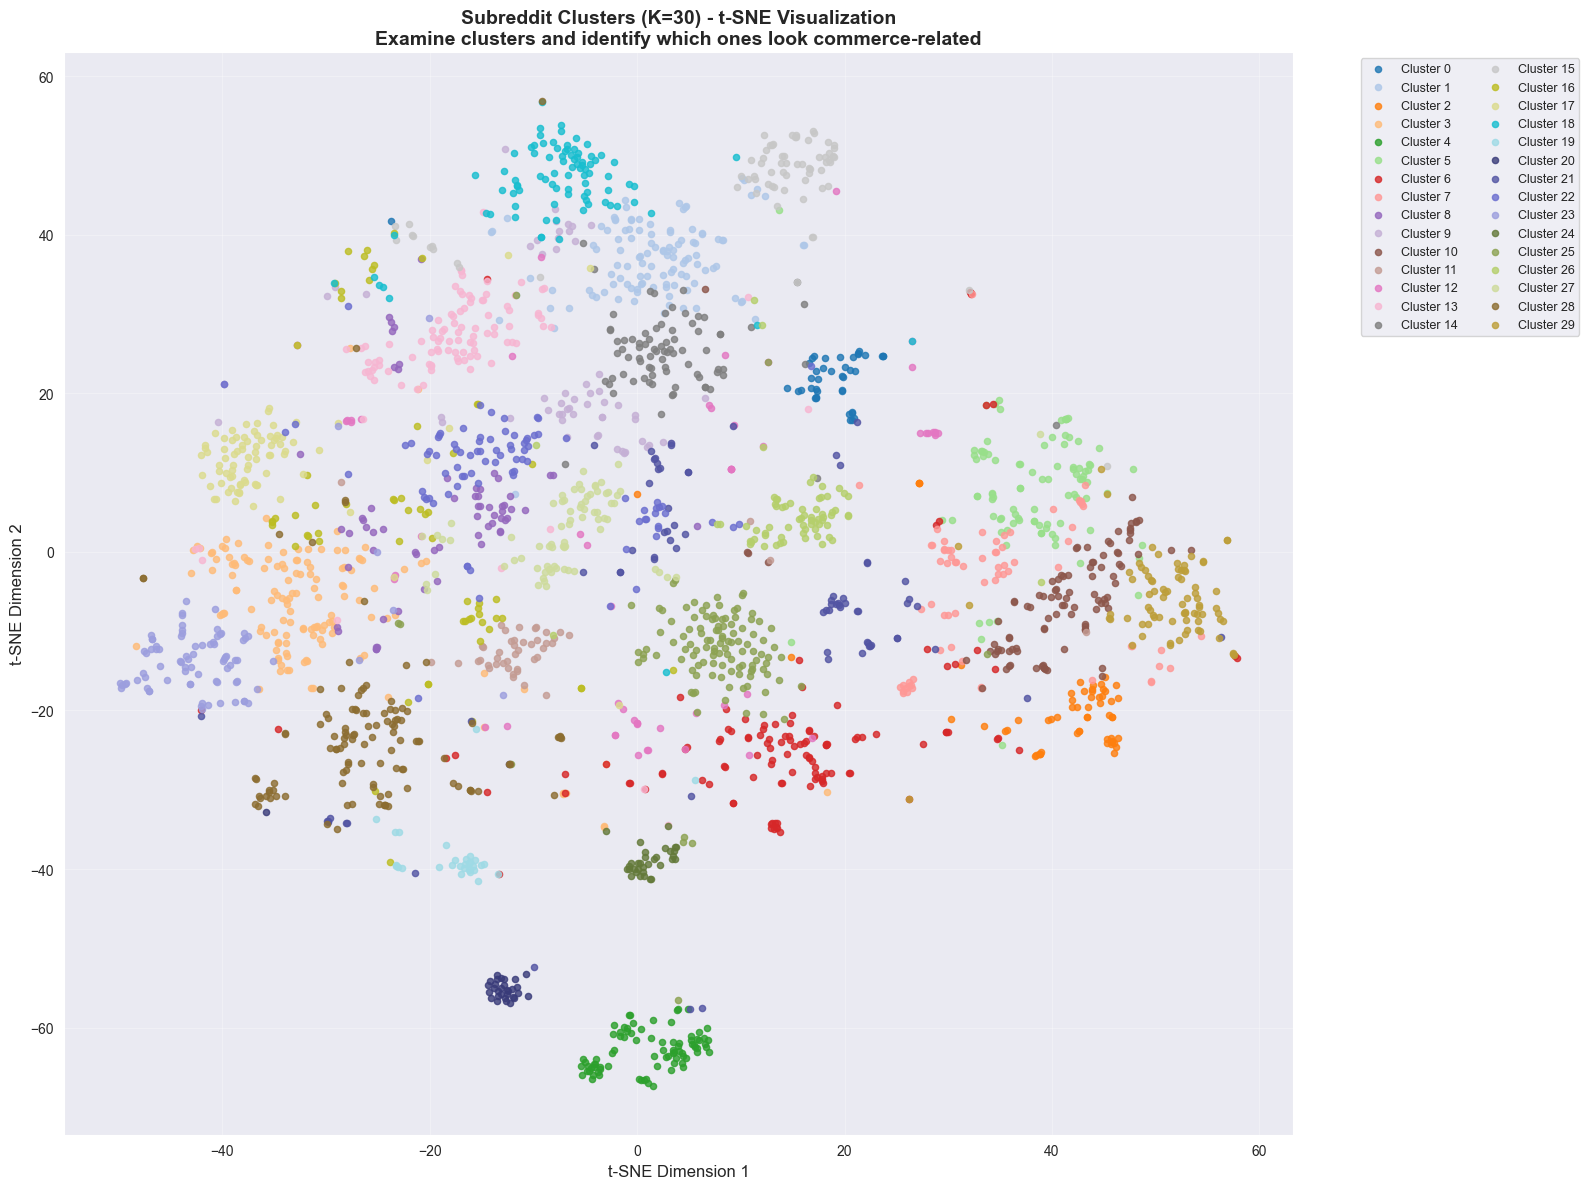

In [13]:
# Based on the plots above, choose your optimal K
optimal_k = 30  # Adjust this based on the metrics above

print(f"\n" + "="*70)
print(f"PERFORMING K-MEANS WITH K={optimal_k}")
print("="*70)

kmeans = KMeans(n_clusters=optimal_k, n_init=50, max_iter=1000, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_pca)

# Create a DataFrame with subreddit-cluster mapping
cluster_df = pd.DataFrame({
    'subreddit': active_subreddits['SUBREDDIT'],
    'cluster': cluster_labels
})

def visualize_clusters_2d(embeddings, subreddit_names, cluster_labels, n_clusters):
    """
    Reduce embeddings to 2D with t-SNE and visualize clusters.
    """
    print(f"\nReducing {embeddings.shape[1]}D embeddings to 2D using t-SNE...")
    print("This may take a few minutes...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create DataFrame for easier plotting
    viz_df = pd.DataFrame({
        'subreddit': subreddit_names,
        'x': embeddings_2d[:, 0],
        'y': embeddings_2d[:, 1],
        'cluster': cluster_labels
    })

    # Plot
    plt.figure(figsize=(16, 12))

    # Create a color map
    colors = get_cluster_colors(n_clusters)

    # Plot each cluster
    for cluster_id in range(n_clusters):
        cluster_data = viz_df[viz_df['cluster'] == cluster_id]
        plt.scatter(cluster_data['x'], cluster_data['y'],
                   c=[colors[cluster_id]],
                   label=f'Cluster {cluster_id}',
                   alpha=0.8,
                   s=20)

    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.title(f'Subreddit Clusters (K={n_clusters}) - t-SNE Visualization\n' +
              'Examine clusters and identify which ones look commerce-related',
              fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('subreddit_clusters_tsne.png', dpi=300, bbox_inches='tight')
    plt.show()

    return viz_df

viz_df = visualize_clusters_2d(embeddings_pca, active_subreddits['SUBREDDIT'], cluster_labels, optimal_k)

## KNN clustering method 2

Here we manually pick clusters related to a theme (e.g., sports) and visualize them.

In [35]:
picked_subreddits = [
    'nfl', 'nba', 'baseball', 'cfb', 'collegebasketball', 'soccer', 'sports', 'mls', 'formula1', 'reddevils'
]

# Centroid based similarity

"""
Function finds similar subreddits based on centroid of all the picked subreddits.
All subreddits are equally important, doesn't matter if they are close to each other or not. (in the graph)
Parameters:
- picked_subreddits: list of subreddit names to compute centroid from
- embeddings: all embeddings
- top_n: self explanatory
Returns:
- DataFrame of top N similar subreddits with similarity scores
"""
def similar_by_centroid(picked_subreddits, embeddings, top_n=10):
    # Isolate embeddings of picked subreddits
    isolate_subreddits = embeddings[embeddings['SUBREDDIT'].isin(picked_subreddits)]

    # Compute centroid
    centroids = isolate_subreddits.drop(columns=['SUBREDDIT']).mean(axis = 0).values

    # Compute cosine similarity between centroid and all subreddits
    similarities = cosine_similarity(embeddings.drop(columns=['SUBREDDIT']), centroids.reshape(1, -1))

    # df of similarities
    results = pd.DataFrame({
        'SUBREDDIT': embeddings['SUBREDDIT'],
        'SIMILARITY': similarities.flatten(),
        'ORIGINAL': embeddings['SUBREDDIT'].isin(picked_subreddits)
    })

    # Remove picked subreddits from results
    results = results[~results['SUBREDDIT'].isin(picked_subreddits)]

    # Sort by similarity and return top N
    results = results.sort_values(by='SIMILARITY', ascending=False).head(top_n)

    return results

"""
For each individual picked_subreddits, find most similar subreddits.
Sometimes subreddits talk about the same topic but are not close to each other in the graph,
this function takes care of that.
"""
def similar_by_max_similarity(picked_subreddits, embeddings, top_n=10):
    # Isolate embeddings of picked subreddits
    isolate_subreddits = embeddings[embeddings['SUBREDDIT'].isin(picked_subreddits)]

    # Compute cos similarity
    similarities = cosine_similarity(isolate_subreddits.drop(columns=['SUBREDDIT']), embeddings.drop(columns=['SUBREDDIT']))

    similarity_df = pd.DataFrame(
        similarities.T,
        columns=picked_subreddits
    )

    # Get max similarity for each subreddit
    results = pd.DataFrame({
        'subreddit': embeddings['SUBREDDIT'],
        'max_similarity': similarity_df.max(axis=1),
        'closest_seed': similarity_df.idxmax(axis=1),
        'is_seed': embeddings['SUBREDDIT'].isin(picked_subreddits)
    })

    results = results.sort_values(by='max_similarity', ascending=False).head(top_n)

    return results

# Print results
centroid = similar_by_centroid(picked_subreddits, subreddits_data, 20)
print("Similar subreddits by centroid:")
display(centroid)

max_sim = similar_by_max_similarity(picked_subreddits, subreddits_data, 20)
print("Similar subreddits by max similarity:")
display(max_sim)


Similar subreddits by centroid:


,SUBREDDIT,SIMILARITY,ORIGINAL
23119,ncaafootball,0.860661,False
18544,ncaa,0.849401,False
10559,theb1g,0.845693,False
14955,bigeast,0.844268,False
23867,miamimls,0.833535,False
14308,acc,0.831292,False
15404,scarletknights,0.830194,False
20484,championsleague,0.827431,False
22199,sec,0.826937,False
2174,worldcup,0.817809,False


Similar subreddits by max similarity:


,subreddit,max_similarity,closest_seed,is_seed
175,cfb,1.000000,collegebasketball,True
76,nfl,1.000000,baseball,True
623,mls,1.000000,reddevils,True
43,nba,1.000000,nfl,True
273,formula1,1.000000,sports,True
208,baseball,1.000000,soccer,True
89,sports,1.000000,cfb,True
547,collegebasketball,1.000000,formula1,True
50,soccer,1.000000,nba,True
347,reddevils,1.000000,mls,True


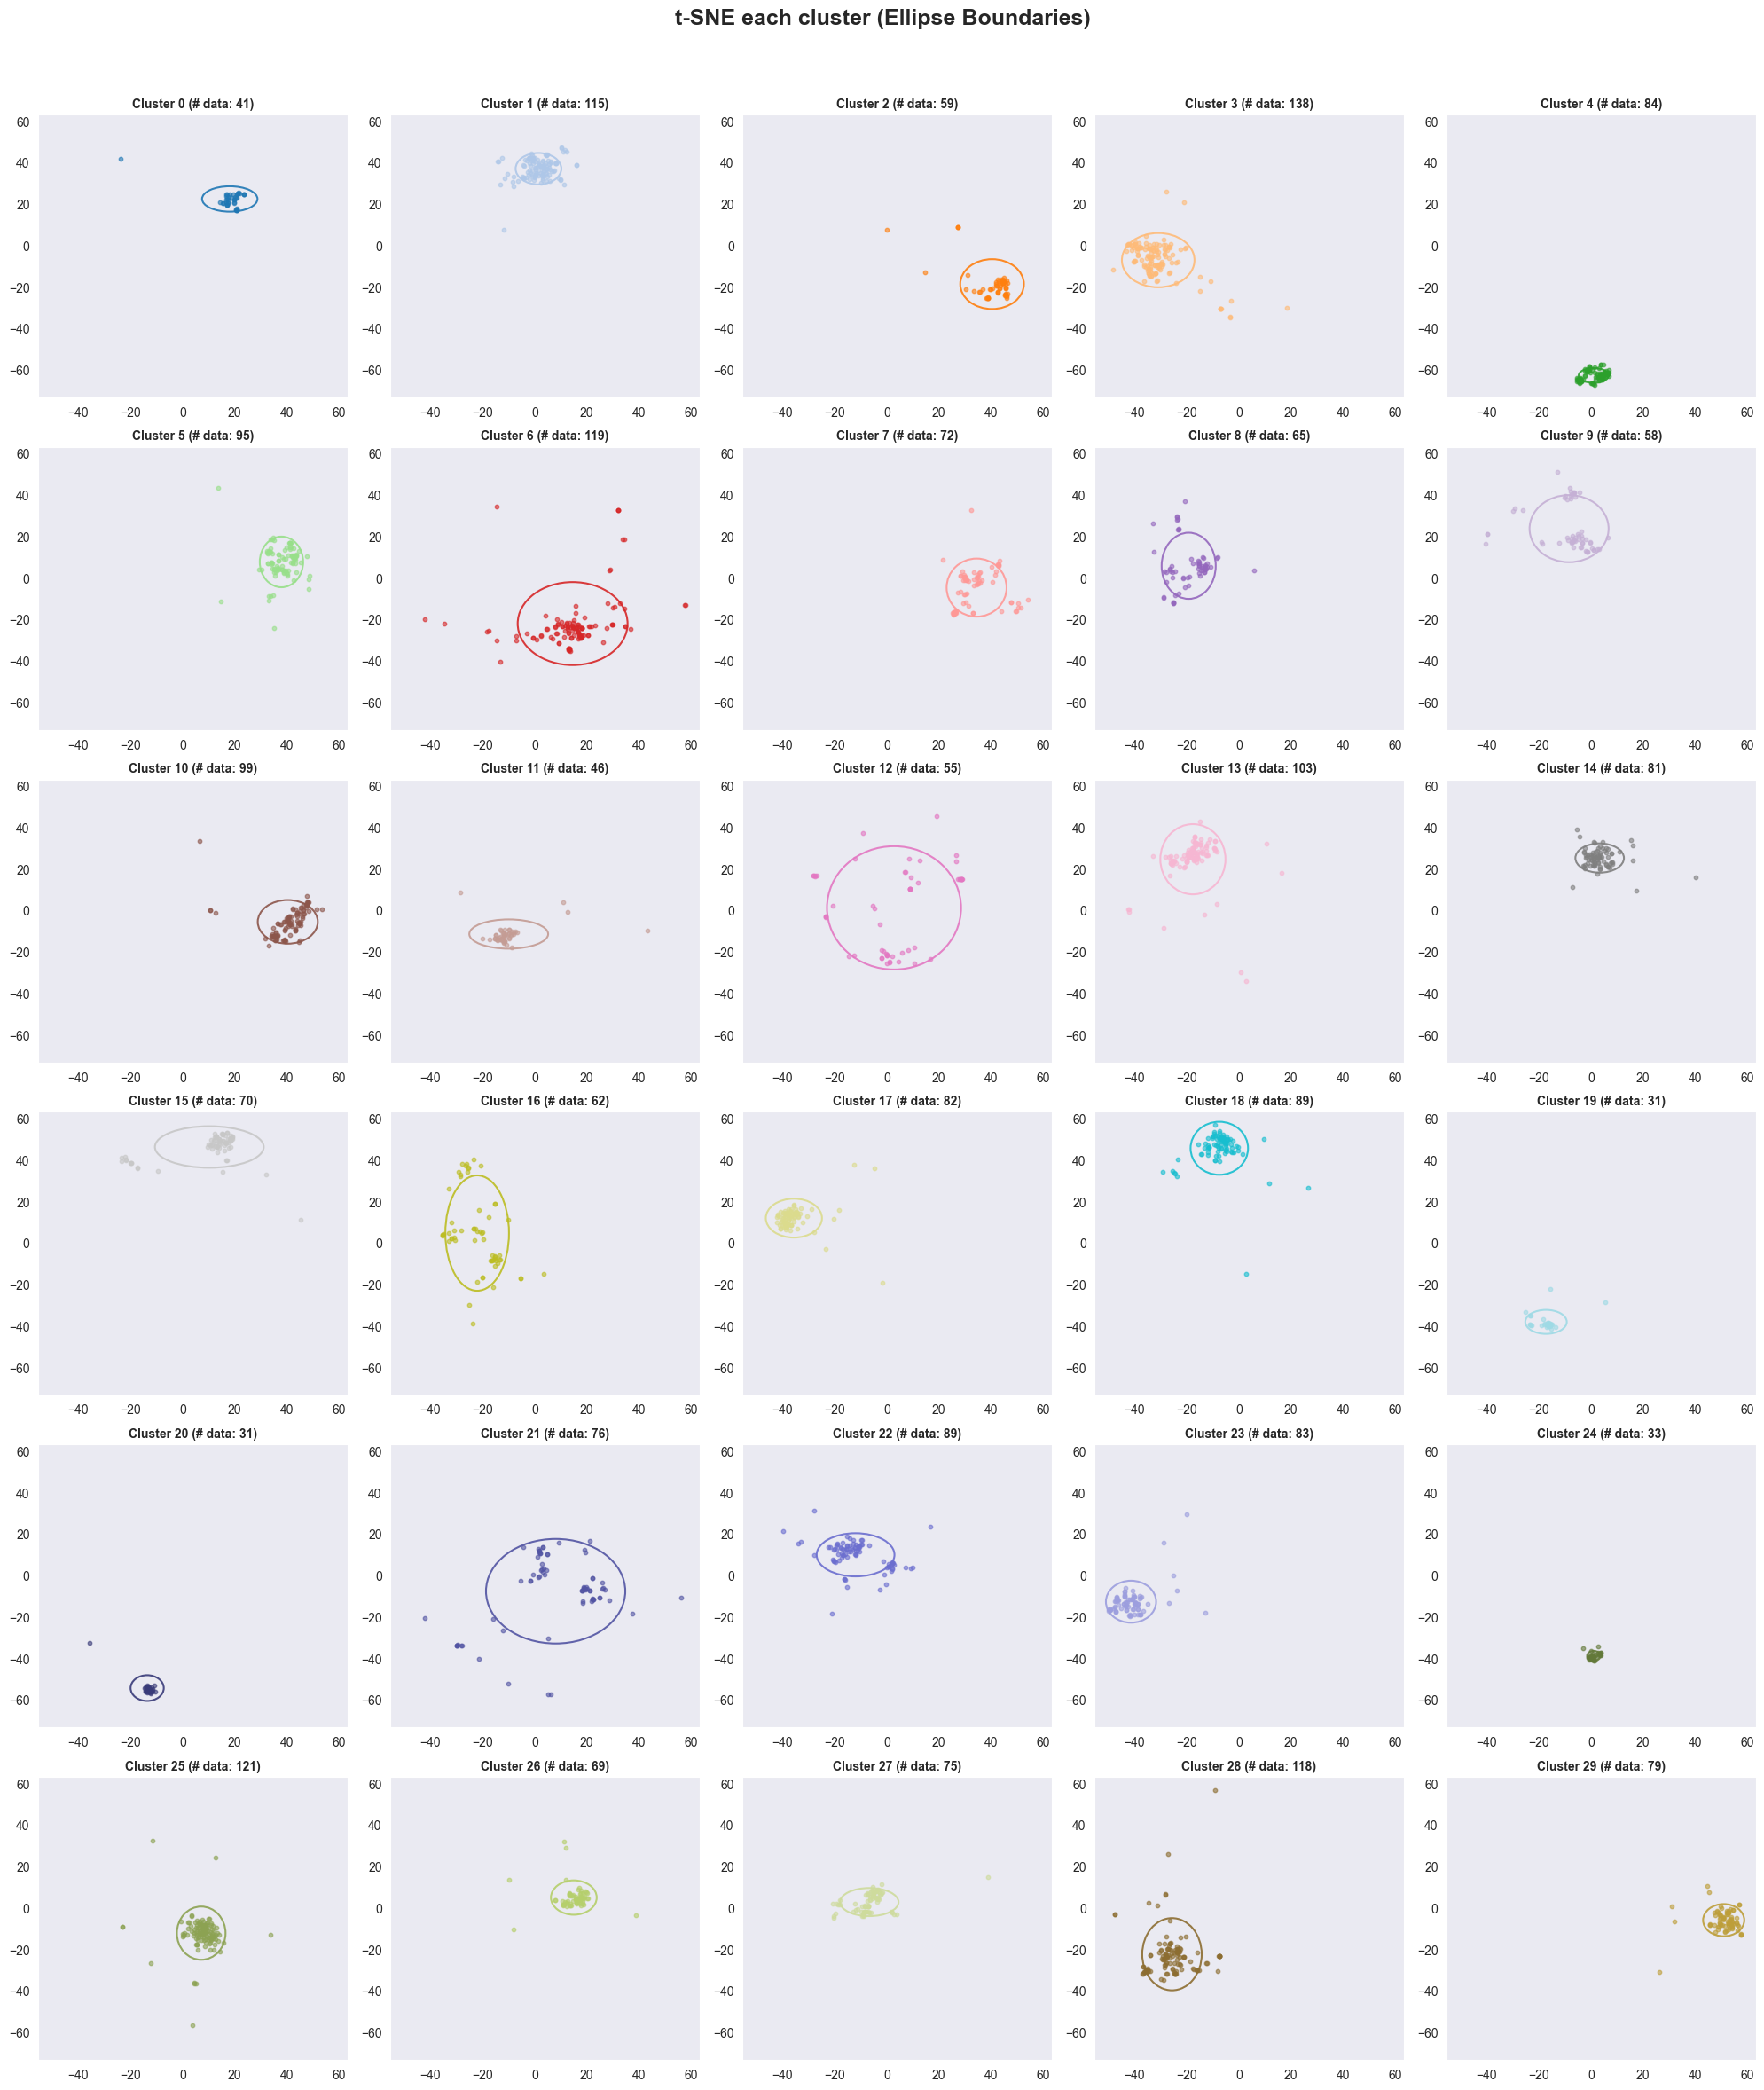

In [16]:
import matplotlib.patches as mpatches
from scipy.spatial import ConvexHull

# -------------------------------------------------------------
# Visualization parameters
# -------------------------------------------------------------
n_clusters = optimal_k         
boundary_type = "ellipse"      # "ellipse", "kde", or "hull"
colors = get_cluster_colors(n_clusters)

# Compute axis limits (same for all subplots within the option)
x_min, x_max = viz_df['x'].min(), viz_df['x'].max()
y_min, y_max = viz_df['y'].min(), viz_df['y'].max()

# Optionally tighten the range slightly (for nicer layout)
x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05
x_min, x_max = x_min - x_padding, x_max + x_padding
y_min, y_max = y_min - y_padding, y_max + y_padding

# Create 6×5 subplots (works best for 30 clusters)
fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten()

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]
    cluster_data = viz_df[viz_df['cluster'] == cluster_id]

    # Plot cluster points
    ax.scatter(cluster_data['x'], cluster_data['y'],
               c=[colors[cluster_id]], alpha=0.6, s=10)

    # OPTION 1 — Elliptical Boundary
    if boundary_type == "ellipse" and len(cluster_data) > 1:
        x_mean, y_mean = cluster_data['x'].mean(), cluster_data['y'].mean()
        x_std, y_std = cluster_data['x'].std(), cluster_data['y'].std()

        ellipse = mpatches.Ellipse(
            (x_mean, y_mean),
            width=3 * x_std,
            height=3 * y_std,
            fill=False,
            edgecolor=colors[cluster_id],
            linewidth=1.5,
            alpha=0.9
        )
        ax.add_patch(ellipse)

    # OPTION 2 — KDE Contour Boundary
    elif boundary_type == "kde" and len(cluster_data) > 5:
        sns.kdeplot(
            x=cluster_data['x'],
            y=cluster_data['y'],
            ax=ax,
            levels=1,
            color=colors[cluster_id],
            linewidths=1.2,
            alpha=0.8
        )

    # OPTION 3 — Convex Hull Boundary
    elif boundary_type == "hull" and len(cluster_data) >= 3:
        points = cluster_data[['x', 'y']].values
        hull = ConvexHull(points)
        for simplex in hull.simplices:
            ax.plot(points[simplex, 0], points[simplex, 1],
                    color=colors[cluster_id], alpha=0.8, linewidth=1.2)

    # Style each subplot
    ax.set_title(f'Cluster {cluster_id} (# data: {len(cluster_data)})', fontsize=10, fontweight='bold')
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(False)


fig.suptitle(f't-SNE each cluster ({boundary_type.capitalize()} Boundaries)',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


## Top active subreddits per cluster

In [17]:
columns_show = ['SUBREDDIT', 'POST_COUNT_SOURCE', 'POST_COUNT_TARGET', 'POST_COUNT_TOTAL']

for id_cluster in range(n_clusters):
    entries_in_cluster = list(viz_df[viz_df['cluster'] == id_cluster]["subreddit"])
    print(f"\nCluster {id_cluster} Top Subreddits:")
    display(total_counts.query(f"SUBREDDIT in {entries_in_cluster}").sort_values(by='POST_COUNT_TOTAL', ascending=False).head(5)[columns_show])


Cluster 0 Top Subreddits:


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
18089,music,620.0,2278.0,2898.0
12578,hiphopheads,441.0,1280.0,1721.0
8566,electronicmusic,173.0,758.0,931.0
12575,hiphopcirclejerk,768.0,30.0,798.0
8461,edmproduction,240.0,487.0,727.0



Cluster 1 Top Subreddits:


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
27886,titlegore,9503.0,33.0,9536.0
24396,shitpost,6658.0,227.0,6885.0
26452,switcharoo,6039.0,3.0,6042.0
12066,hailcorporate,5360.0,263.0,5623.0
9070,evenwithcontext,2383.0,7.0,2390.0



Cluster 2 Top Subreddits:


...

,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
22776,relationships,336.0,2712.0,3048.0
28316,trees,1016.0,1693.0,2709.0
28720,twoxchromosomes,257.0,2188.0,2445.0
8086,drugs,603.0,1322.0,1925.0
6869,darknetmarkets,619.0,1095.0,1714.0



Cluster 28 Top Subreddits:


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
30618,worldnews,303.0,9944.0,10247.0
9022,europe,481.0,2676.0,3157.0
13572,india,1113.0,1818.0,2931.0
4420,canada,491.0,1961.0,2452.0
29022,unitedkingdom,475.0,1438.0,1913.0



Cluster 29 Top Subreddits:


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
10901,gaming,2072.0,6097.0,8169.0
10870,games,1122.0,2200.0,3322.0
10910,gamingcirclejerk,2532.0,73.0,2605.0
7347,destinythegame,558.0,1399.0,1957.0
21753,ps4,548.0,966.0,1514.0


In [18]:
list(viz_df[viz_df['cluster'] == 2]["subreddit"]) # related to esports

['leagueoflegends',
 'globaloffensive',
 'dota2',
 'overwatch',
 'hearthstone',
 'wow',
 '2007scape',
 'smite',
 'runescape',
 'pathofexile',
 'heroesofthestorm',
 'summonerschool',
 'guildwars2',
 'h1z1',
 'starcraft',
 'playrust',
 'osugame',
 'twitch',
 'teamredditteams',
 'blackdesertonline',
 'diablo',
 'mindcrack',
 'archeage',
 'diablo3',
 'wildstar',
 'customhearthstone',
 'wowguilds',
 'learndota2',
 'csgobetting',
 'ice_poseidon',
 'competitiveoverwatch',
 'hearthstonecirclejerk',
 'wowservers',
 'clg',
 'competitivehs',
 'overwatchuniversity',
 'teamsolomid',
 'destiny',
 'livestreamfail',
 'esports',
 'forsen',
 'dota2circlejerk',
 'uhccourtroom',
 'truedota2',
 'allthingsterran',
 'dotamasterrace',
 'starcraftcirclejerk',
 'mindcrackcirclejerk',
 'leagueoflegendsmeta',
 'cloud9',
 'leagueofmeta',
 'circloljerk',
 'dota2modding',
 'dota2betting',
 'supportlol',
 'wowcirclejerk',
 'soargaming',
 'mindcrackdiscussion',
 'thecannibalcaverns']

In [19]:
list(viz_df[viz_df['cluster'] == 19]["subreddit"]) # related to soccer

['fifa',
 'soccer',
 'sports',
 'formula1',
 'reddevils',
 'gunners',
 'cricket',
 'liverpoolfc',
 'mls',
 'boxing',
 'poker',
 'rugbyunion',
 'tennis',
 'chelseafc',
 'coys',
 'soccercirclejerk',
 'soccerstreams',
 'barca',
 'realmadrid',
 'mcfc',
 'aleague',
 'naslsoccer',
 'indycar',
 'wec',
 'footballdownload',
 'ligamx',
 'atletico',
 'uscr',
 'jleague',
 'futebol',
 'soccernerd']

# Occurrences of subreddits over time

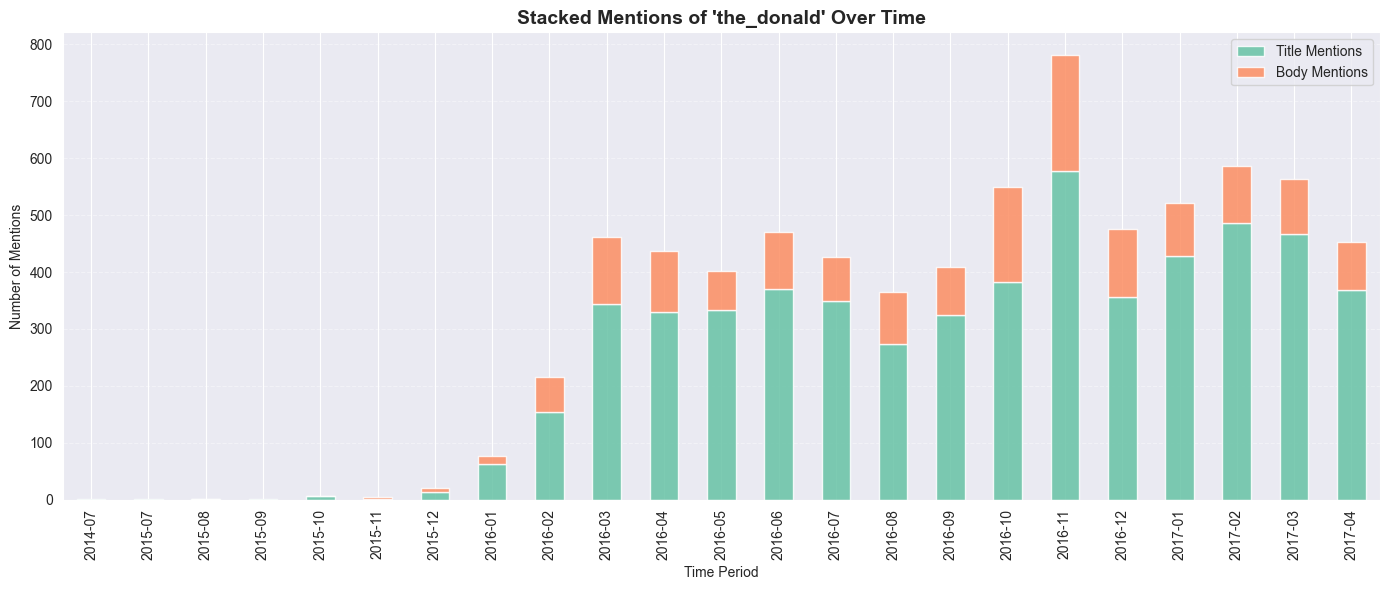

In [20]:
# Choose subreddit pattern
# pattern = "leagueoflegends"
# pattern = "dota2"
pattern = "the_donald"
# pattern = "gaming"
# pattern = "soccer"
# pattern = "formula1"
# Copy to avoid SettingWithCopyWarning
tf = title_data
bf = body_data

# Flag relevant rows
tf["is_relevant"] = (
    (tf["SOURCE_SUBREDDIT"] == pattern) |
    (tf["TARGET_SUBREDDIT"] == pattern)
)
bf["is_relevant"] = (
    (bf["SOURCE_SUBREDDIT"] == pattern) |
    (bf["TARGET_SUBREDDIT"] == pattern)
)

# Convert timestamps safely
tf["TIMESTAMP"] = pd.to_datetime(tf["TIMESTAMP"], errors="coerce")
bf["TIMESTAMP"] = pd.to_datetime(bf["TIMESTAMP"], errors="coerce")

# Filter relevant subsets
df = tf[tf["is_relevant"] ]#& (tf["TIMESTAMP"].dt.year == 2015)]
df_body = bf[bf["is_relevant"]]# & (bf["TIMESTAMP"].dt.year == 2015)]

# --- Aggregation period ---
period = "M"  # or "W" for weekly
if period == "M":
    figsize = (14, 6)
elif period == "W":
    figsize = (24, 8)
df = tf.loc[tf["is_relevant"]].assign(PERIOD=lambda x: x["TIMESTAMP"].dt.to_period(period))
df_body = bf.loc[bf["is_relevant"]].assign(PERIOD=lambda x: x["TIMESTAMP"].dt.to_period(period))

# --- Count mentions per period ---
counts_title = df.groupby("PERIOD").size()
counts_body = df_body.groupby("PERIOD").size()

# Combine into one DataFrame for stacked plotting
counts_df = pd.DataFrame({
    "Title Mentions": counts_title,
    "Body Mentions": counts_body
}).fillna(0)

# --- Plot ---
counts_df.plot(
    kind="bar",
    stacked=True,
    figsize=figsize,
    color=["#66c2a5", "#fc8d62"],
    alpha=0.85
)

plt.title(f"Stacked Mentions of '{pattern}' Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Time Period")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [21]:
start_date = "2015-10-01"
end_date = "2015-10-31"

# Filter: subreddit match + time range
filtered_df = title_data[
    (title_data["TARGET_SUBREDDIT"] == "leagueoflegends") &
    (title_data["TIMESTAMP"].between(start_date, end_date))
]
display(filtered_df.sort_values(by='TIMESTAMP').head(5))

filtered_bf = body_data[
    (body_data["TARGET_SUBREDDIT"] == "leagueoflegends") &
    (body_data["TIMESTAMP"].between(start_date, end_date))
]

display(filtered_bf.sort_values(by='TIMESTAMP').head(5))

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES,is_relevant
257607,games,leagueoflegends,3n3dhus,2015-10-01 13:13:27,1,"85.0,72.0,0.752941176471,0.0235294117647,0.164...",False
258256,retiredgif,leagueoflegends,3n908as,2015-10-02 08:24:11,1,"58.0,51.0,0.810344827586,0.0,0.137931034483,0....",False
258184,teamsolomid,leagueoflegends,3n8gnms,2015-10-02 16:25:58,1,"36.0,30.0,0.777777777778,0.0,0.25,0.1944444444...",False
258088,datguylirik,leagueoflegends,3n7pens,2015-10-02 17:29:56,1,"71.0,63.0,0.845070422535,0.0140845070423,0.140...",False
258560,dotamasterrace,leagueoflegends,3nbsjms,2015-10-03 11:00:33,1,"52.0,45.0,0.826923076923,0.0,0.173076923077,0....",False


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES,is_relevant
129368,drama,leagueoflegends,3n4rlxs,2015-10-01 16:37:07,1,"1149.0,1021.0,0.743255004352,0.0191470844212,0...",False
131631,openbroke,leagueoflegends,3o3ujts,2015-10-01 17:27:12,1,"16980.0,16575.0,0.741048292108,0.0424028268551...",False
129449,invictusgaming,leagueoflegends,3n65vts,2015-10-02 01:26:52,1,"1903.0,1759.0,0.585391487126,0.0451918024172,0...",False
129446,cloud9,leagueoflegends,3n63css,2015-10-02 01:40:15,1,"857.0,732.0,0.752625437573,0.0210035005834,0.0...",False
129481,summonerschool,leagueoflegends,3n6n0zs,2015-10-02 03:51:57,1,"328.0,289.0,0.783536585366,0.00609756097561,0....",False


# Additional datasets

In [22]:
events_data

,ADM_name,ISO3,Date,Name,Type
44,Aruba,ABW,2014-01-01,New Year's Day,Public holiday
45,Aruba,ABW,2014-01-25,Betico Croes' Birthday,Public holiday
46,Aruba,ABW,2014-03-03,Carnival Monday,Public holiday
47,Aruba,ABW,2014-03-18,National Anthem and Flag Day,Public holiday
48,Aruba,ABW,2014-04-18,Good Friday,Public holiday
...,...,...,...,...,...
44379,Palestine,PSE,2017-04-25,Prophet's Ascension,Public holiday
44386,Palestine,PSE,2014-01-13,Prophet's Birthday,Public holiday
44387,Palestine,PSE,2015-01-03,Prophet's Birthday,Public holiday
44388,Palestine,PSE,2015-12-24,Prophet's Birthday,Public holiday


In [23]:
events_data.Name.value_counts()[:50]

Name
Christmas Day                         558
Good Friday                           547
Easter Monday                         467
New Year's Day                        426
Independence Day                      368
Easter Sunday                         319
New Year's Eve                        295
Valentine's Day                       208
Boxing Day                            206
Christmas Eve                         201
Labor Day / May Day                   171
Eid al-Adha                           158
Mother's Day                          158
Ascension Day                         151
Eid al-Fitr                           145
Whit Monday                           141
New Year                              140
All Saints' Day                       139
Father's Day                          136
Assumption of Mary                    131
Holy Saturday                         127
Labour Day                            126
Constitution Day                      120
International Women's Day    

In [24]:
events_data[events_data['Name'] == 'Family Day']["ADM_name"].unique()

array(['Canada', 'Moldova', 'Mongolia', 'Mozambique', 'Namibia',
       'Ukraine', 'Vanuatu', 'South-africa'], dtype=object)

In [25]:
# taken from https://www.kaggle.com/datasets/hbakker/esports-200-tournaments
df_esports = pd.read_csv("src/esports_tournaments_2014_2017.csv")
df_esports.head(5)

,GameID,TournamentName,StartDate,EndDate,City,Country,TeamPlay,TotalUSDPrize,year
0,5079.0,Call of Duty Championship 2014,3/28/14,3/30/14,Los Angeles,United States,1.0,1000000.0,14.0
1,6418.0,The International 2014,7/8/14,7/21/14,Seattle/Washington,United States,1.0,10931103.0,14.0
2,7376.0,LoL 2014 World Championship,9/18/14,10/19/14,Taipei/Singapore,Taiwan/Singapore,1.0,2130000.0,14.0
3,9205.0,DAC 2015,1/5/15,2/9/15,Shangai,China,1.0,3057521.0,15.0
4,8885.0,Smite World Championship 2015,1/9/15,1/1/15,Atlanta,United States,1.0,2612259.0,15.0


In [26]:
# taken from https://www.kaggle.com/datasets/irkaal/english-premier-league-results/data98
df_epl = pd.read_csv("src/english-premier-league-results_2014-01-2017-04.csv")
df_epl.head(5)

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,2013-14,2014-01-01T00:00:00Z,Arsenal,Cardiff,2,0,H,0.0,0.0,D,...,6.0,2.0,12.0,2.0,6.0,11.0,1.0,2.0,0.0,0.0
1,2013-14,2014-01-01T00:00:00Z,Crystal Palace,Norwich,1,1,D,1.0,1.0,D,...,4.0,5.0,9.0,4.0,12.0,10.0,2.0,1.0,0.0,1.0
2,2013-14,2014-01-01T00:00:00Z,Fulham,West Ham,2,1,H,1.0,1.0,D,...,11.0,3.0,12.0,4.0,6.0,5.0,2.0,1.0,0.0,1.0
3,2013-14,2014-01-01T00:00:00Z,Liverpool,Hull,2,0,H,1.0,0.0,H,...,6.0,0.0,3.0,4.0,15.0,15.0,1.0,2.0,0.0,0.0
4,2013-14,2014-01-01T00:00:00Z,Man United,Tottenham,1,2,A,0.0,1.0,A,...,6.0,4.0,13.0,2.0,7.0,7.0,2.0,1.0,0.0,0.0


In [27]:
# taken from https://www.kaggle.com/datasets/timoboz/superbowl-history-1967-2020
df_superbowl = pd.read_csv("src/superbowl_2014_2017.csv")
df_superbowl.head(5)

,Date,SB,Winner,Winner Pts,Loser,Loser Pts,MVP,Stadium,City,State
0,Feb 5 2017,LI (51),New England Patriots,34,Atlanta Falcons,28,Tom Brady,NRG Stadium,Houston,Texas
1,Feb 7 2016,50,Denver Broncos,24,Carolina Panthers,10,Von Miller,Levi's Stadium,Santa Clara,California
2,Feb 1 2015,XLIX (49),New England Patriots,28,Seattle Seahawks,24,Tom Brady,University of Phoenix Stadium,Glendale,Arizona
3,Feb 2 2014,XLVIII (48),Seattle Seahawks,43,Denver Broncos,8,Malcolm Smith,MetLife Stadium,East Rutherford,New Jersey
